In [2]:
import requests
from bs4 import BeautifulSoup
import os
import glob
import matplotlib.pyplot as plt 
import xarray as xr
import numpy as np

ModuleNotFoundError: No module named 'bs4'

In [10]:
# # Function to download and save data from a given link
def download_data(link, save_path):
    response = requests.get(link)
    
    if response.status_code == 200:
        with open(save_path, 'w', encoding='utf-8') as file:
            file.write(response.text)
        print(f"Data from {link} saved to {save_path}")
    else:
        print(f"Failed to retrieve data from {link}. Status code: {response.status_code}")

# URL of the website with the table of links
website_url = 'https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Boulder,%20Colorado/100%20Meter%20Average%20Files/'



# Make a request to the website
response = requests.get(website_url)

if response.status_code == 200:
    soup = BeautifulSoup(response.text, 'html.parser')

    # Locate the table containing links
    table = soup.find('table')

    # Assuming links are in the 'a' tags within the table
    links = table.find_all('a')

    # Create a directory to save the text files
    if not os.path.exists('downloaded_data'):
        os.makedirs('downloaded_data')

    for link in links:
        href = link.get('href')
        if href.endswith('.l100'):
            # Construct the absolute URL if the link is relative
            full_url = website_url + href if not href.startswith('http') else href
            
            # Generate a filename based on the link
            filename = os.path.join('downloaded_data', os.path.basename(href))

            # Download and save the data
            download_data(full_url, filename)
else:
    print(f"Failed to retrieve the website. Status code: {response.status_code}")


Data from https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Boulder,%20Colorado/100%20Meter%20Average%20Files/abl001_1967_04_27_16.l100 saved to downloaded_data/abl001_1967_04_27_16.l100
Data from https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Boulder,%20Colorado/100%20Meter%20Average%20Files/abl002_1967_05_22_16.l100 saved to downloaded_data/abl002_1967_05_22_16.l100
Data from https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Boulder,%20Colorado/100%20Meter%20Average%20Files/abl003_1967_05_25_16.l100 saved to downloaded_data/abl003_1967_05_25_16.l100
Data from https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Boulder,%20Colorado/100%20Meter%20Average%20Files/abl004_1967_06_15_17.l100 saved to downloaded_data/abl004_1967_06_15_17.l100
Data from https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Boulder,%20Colorado/100%20Meter%20Average%20Files/abl005_1967_06_22_20.l100 saved to downloaded_data/abl005_1967_06_22_20.l100
Data from https://gml.noaa.gov/aftp/data/ozwv/Ozonesonde/Boulder,%20Colorado/100

In [163]:
def combine_and_rename(df):
    # Get the column names
    column_names = df.columns.tolist()

    # Get the first row values
    first_row = df.iloc[0].tolist()

    # Combine the column names and the first row values
    new_column_names = [f"{column} - {value}" for column, value in zip(column_names, first_row)]

    # Rename the dataframe columns
    df.columns = new_column_names

    return df.iloc[1:,:]

In [171]:
def xr_from_csv(f):
    try: 
        df = pd.read_csv(f, skiprows=26, sep='\s+', engine='python')
        df = combine_and_rename(df)
        df = df.astype(float)
    except ValueError:
        df = pd.read_csv(f, skiprows=27, sep='\s+', engine='python')
        df = combine_and_rename(df)
        df = df.astype(float)

    # keep going
    tstr = f.split("/")[-1].split("_")

    # this is the time ...
    thetime= pd.to_datetime(tstr[1] + "-" + tstr[2] + "-" + tstr[3])

    # now do some fixing of the data...
    df = df.sort_values(by='Press - hPa')
    # interpolate it to a standard pressure grid
    # the actual pressure levels change a little bit from day to day
    # but most of the ozone is up high so this prob doesn't matter 
    df_interpO3 = np.interp(np.linspace(10, 750, 100), df['Press - hPa'], df['Ozone.1 - ppmv'])
    df_interpTC = np.interp(np.linspace(10, 750, 100), df['Press - hPa'], df['Temp - C'])
    df_interpRH = np.interp(np.linspace(10, 750, 100), df['Press - hPa'], df['Hum - %'])

    xrds = xr.Dataset(data_vars={"rh":(["time", "pressure"], df_interpRH.reshape(-1,100)),
                                 "tc":(["time", "pressure"], df_interpTC.reshape(-1,100)),
                                 "o3":(["time", "pressure"], df_interpO3.reshape(-1,100)),
                                 }, 
                      coords={"pressure":(np.linspace(10, 750, 100)), 
                             "time": np.array([thetime])})

    #ds_list.append(xrds)
    return xrds
    

In [173]:
yearlist = range(1967, 2024)

xrds_list = []
name = "all_sondes_%s-%s.nc"%(1967, 2023)

for yr in yearlist:
    flist = list(glob.glob("./downloaded_data/*%s*.l100"%yr))

    for f in flist:
        xrds_list.append(xr_from_csv(f))

    print(yr)
    
# now lets' concat and save the file 
xr.concat(xrds_list, dim='time').to_netcdf("./ozone_files/"+name)



1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984


1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [2]:
name = "all_sondes_%s-%s.nc"%(1967, 2023)
allds = xr.open_dataset("./ozone_files/"+name)
allds=allds.sortby('time')


In [4]:
allds.o3

<xarray.DataArray 'o3' (time: 2107, pressure: 100)>
[210700 values with dtype=float64]
Coordinates:
  * pressure  (pressure) float64 10.0 17.47 24.95 32.42 ... 735.1 742.5 750.0
  * time      (time) datetime64[ns] 1967-04-27 1967-05-22 ... 2023-12-27

In [7]:
historic=allds.isel(time=slice(0,800)).median(dim='time')#.tc.plot(y='pressure', color='red')
current=allds.isel(time=slice(800,2100)).median(dim='time')#.tc.plot(y='pressure', color='blue')

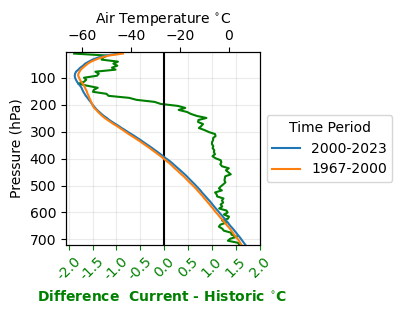

In [311]:
fig,ax=plt.subplots(figsize=(2.5,2.5))



ax2 = ax.twiny()
ax.plot(current.tc - historic.tc, allds.pressure, color='green')
ax.axvline(0, color='black')
ax.tick_params(axis='x', colors='green')

ax2.plot(current.tc, allds.pressure, label='2000-2023')
ax2.plot(historic.tc, allds.pressure,  label='1967-2000')
#leg=ax2.legend()

leg=ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))


leg.set_title("Time Period")

ax2.set_ylim(720,5)
ax.set_ylim(720,5)
ax.set_xticks([-2,-1.5, -1, -.5, 0, .5, 1., 1.5, 2.])
ax.set_xticklabels(ax.get_xticks(), rotation=45)
ax.set_yticks([700,600,500,400,300,200,100])
ax.grid(alpha=.25)
ax2.set_xlabel("Air Temperature $^{\circ}$C")
ax.set_xlabel("Difference  Current - Historic $^{\circ}$C ", color='green', fontweight='bold')
ax.set_ylabel("Pressure (hPa)")


plt.savefig("/Volumes/Transcend/NewWebsite4Real/willblog/images/sonde_warming.png", dpi=200, bbox_inches='tight')

In [279]:
ls /Volumes/Transcend/NewWebsite4Real/images

IMG_0130.jpeg*	backwards.jpg*	ds.jpg*
ausbygde.jpg*	diane.jpg*	stingerwskis.jpg*


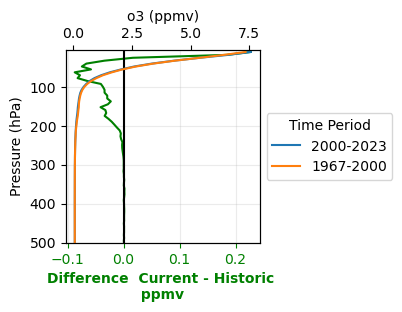

In [22]:
fig,ax=plt.subplots(figsize=(2.5,2.5))
import numpy as np



ax2 = ax.twiny()
ax.plot(current.o3 - historic.o3, allds.pressure, color='green')
ax.axvline(0, color='black')
ax.tick_params(axis='x', colors='green')

ax2.plot(current.o3, allds.pressure, label='2000-2023')
ax2.plot(historic.o3, allds.pressure,  label='1967-2000')
#leg=ax2.legend()

leg=ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))


leg.set_title("Time Period")

ax2.set_ylim(500,5)
ax.set_ylim(500,5)
#ax.set_xticks([-2,-1.5, -1, -.5, 0, .5, 1., 1.5, 2.])
#ax.set_xticklabels(ax.get_xticks(), rotation=45)
#ax.set_yticks([700,600,500,400,300,200,100])
ax.grid(alpha=.25)
ax2.set_xlabel("o3 (ppmv)")
ax.set_xlabel("Difference  Current - Historic \n ppmv ", color='green', fontweight='bold')
ax.set_ylabel("Pressure (hPa)")


plt.savefig("/Volumes/Transcend/NewWebsite4Real/willblog/images/sonde_o3hole.png", dpi=200, bbox_inches='tight')

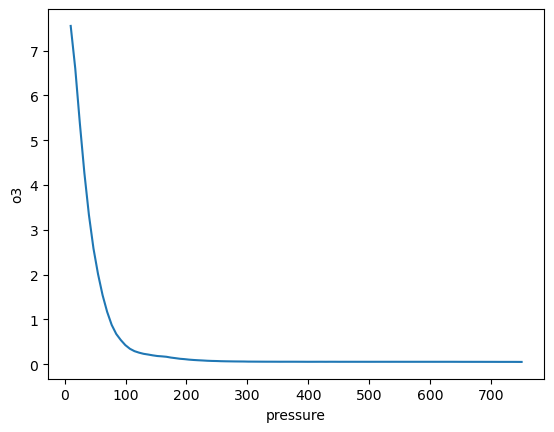

In [243]:
current.o3.plot()